# **🗨️ Text Embeddings**

---
---
# **CLIP Text Embeddings**

- CLIP converts each text into a 512-dimensional embedding vector.
- These embeddings are in the same space as CLIP’s image embeddings → meaning you can compare text ↔ image directly.
- Normalization (L2 norm) makes similarity search more stable (cosine similarity).

In [1]:
import torch
from transformers import CLIPTokenizer, CLIPModel

# Load pretrained CLIP (text + vision)
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

# Example texts
texts = [
    "a photo of a dog",
    "a picture of a cat",
    "machine learning is fascinating"
]

# Tokenize input
inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)

# Get text embeddings
with torch.no_grad():
    text_features = model.get_text_features(**inputs)

# Normalize embeddings (common practice for similarity search)
text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)

print("Embedding shape:", text_features.shape)   # (3, 512)
print("First 5 numbers:", text_features[0][:5])

Embedding shape: torch.Size([3, 512])
First 5 numbers: tensor([ 0.0087,  0.0258, -0.0387,  0.0123, -0.0105])


---
Embeddings are high-dimensional (here 512-D), so the trick is to project them down to 2D or 3D for visualization. Two common ways:
- PCA (Principal Component Analysis) → fast, linear projection.
- t-SNE / UMAP → nonlinear, better for capturing semantic clusters.

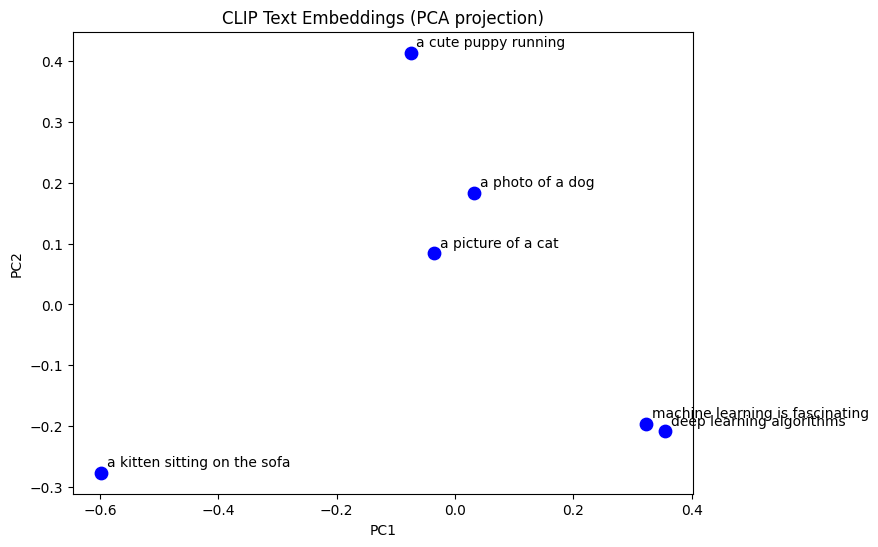

In [ ]:
import torch  # PyTorch, used to run CLIP and manage tensors.
from transformers import CLIPTokenizer, CLIPModel  # Hugging Face library for pretrained models.
from sklearn.decomposition import PCA  # from scikit-learn, reduces embeddings to 2D.
import matplotlib.pyplot as plt  # used for plotting.

# Loads the pretrained CLIP model (ViT-B/32 variant).
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")  # gives you the text & image encoder.
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")  # converts text → tokens (numbers the model understands).

# Example texts
texts = [
    "a photo of a dog",
    "a picture of a cat",
    "machine learning is fascinating",
    "a cute puppy running",
    "a kitten sitting on the sofa",
    "deep learning algorithms"
]

# Tokenize and embed
inputs = tokenizer(  # turns each text into token IDs + attention masks (like one-hot-ish).
    texts,
    return_tensors="pt",  # return PyTorch tensors.
    padding=True, truncation=True  # ensures equal length sequences.
)
with torch.no_grad():  # disables gradient tracking (saves memory, faster inference).
    text_features = model.get_text_features(**inputs)  # runs text encoder, outputs 512-dimensional embeddings.

# Normalize
text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)  # L2 normalization (common practice for similarity search)
embeddings = text_features.cpu().numpy()  # moves tensors to CPU & converts to NumPy array for PCA.

# Reduce to 2D with PCA
pca = PCA(n_components=2)  # project 512-D embeddings into 2D for visualization.
reduced = pca.fit_transform(embeddings)  # project 512-D embeddings into 2D for visualization.

# Plot
plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c="blue", s=80)

for i, txt in enumerate(texts):
    plt.annotate(txt, (reduced[i,0]+0.01, reduced[i,1]+0.01))

plt.title("CLIP Text Embeddings (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

---
---
---